# Allergen Detection from Ingredient Lists
## Multi-label Classification with MobileBERT

This notebook trains a multi-label classifier to detect 8 allergens from product ingredient texts.

## Overview
Trains MobileBERT model for multi-label allergen classification.

## Workflow
1. Load and prepare data
2. Split into train/val/test
3. Train model with weighted loss
4. Evaluate and compute thresholds


## 1. Setup & Installations

In [1]:
!pip install -q transformers datasets scikit-learn torch accelerate tensorboardX tensorboard 
import sys
!{sys.executable} -m pip install iterative-stratification

In [2]:
import pandas as pd
import numpy as np
import ast
import re
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, multilabel_confusion_matrix
from scipy.special import expit
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Imports completed.")

Imports completed.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load and Prepare Data

In [4]:
# Load dataset
df = pd.read_csv("../data/final/labeled_dataset.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1057, 15)


,code,brands,product_name_en,ingredients_text_en,ingredients,ingredients_tags,allergens_tags,traces_tags,categories,countries_tags,ingredients_cleaned,ingredient_tokens,detected_allergens,official_allergens_mapped,traces_allergens
0,4804888901277,NaN,ok! fruit drink,"water, refined sugar, citric acid, artificial ...","[{""percent_max"":100.0,""percent_min"":12.5,""is_i...",['en:water' 'en:sugar' 'en:added-sugar' 'en:di...,[],[],NaN,['en:philippines'],"water, refined sugar, citric acid, artificial ...","['water', 'refined sugar', 'citric acid', 'art...",[],[],[]
1,4804888889735,"Zest-O,Zesto",Big Zesto Apple 250,"water, sugar, apple juice concentrate, citric ...","[{""percent_max"":100.0,""percent_min"":59.1999999...",['en:water' 'en:sugar' 'en:added-sugar' 'en:di...,[],[],"Beverages and beverages preparations,Beverages...",['en:philippines'],"water, sugar, apple juice concentrate, citric ...","['water', 'sugar', 'apple juice concentrate', ...",[],[],[]
2,4891208040181,Oishi,Oishi Rinbee Cheese Sticks,"wheat, tapioca starch, vegetable oil, coconut ...","[{""percent_max"":100.0,""percent_min"":3.84615384...",['en:wheat' 'en:cereal' 'en:tapioca' 'en:starc...,['en:fish' 'en:gluten' 'en:milk' 'en:soybeans'],['en:crustaceans' 'en:eggs' 'en:gluten' 'en:mo...,"Snacks,Cheese Sticks,Corn Snacks,Chips,Crackers",['en:philippines'],"wheat, tapioca starch, vegetable oil, coconut ...","['wheat', 'tapioca starch', 'vegetable oil', '...","['milk', 'tree_nuts', 'wheat', 'fish']",[],[]
3,6223005620927,Alda,Pasta,durum wheat semolina + water,"[{""percent_max"":100.0,""percent_min"":100.0,""is_...",['en:durum-wheat-semolina-water'],[],[],"Pas, en:pastas",['en:philippines'],durum wheat semolina water,['durum wheat semolina water'],['wheat'],[],[]
4,4800221244766,Ensure,Ensure Gold,"hydrolyzed corn starch, vegetable oils (high o...","[{""percent_max"":100.0,""percent_min"":6.66666666...",['en:hydrolyzed-corn-starch' 'en:vegetable-oil...,['en:milk' 'en:soybeans'],[],NaN,['en:philippines'],"hydrolyzed corn starch, vegetable oils ,high o...","['hydrolyzed corn starch', 'vegetable oils', '...","['milk', 'soy']",[],[]


In [5]:
# Parse detected_allergens (stored as string lists)
df["detected_allergens"] = df["detected_allergens"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Define allergen classes (8 classes)
ALLERGENS = ["milk", "eggs", "peanuts", "tree_nuts", "soy", "wheat", "fish", "shellfish"]

# Encode labels
def encode_labels(allergens):
    return [1 if a in allergens else 0 for a in ALLERGENS]

df["labels"] = df["detected_allergens"].apply(encode_labels)

# Clean ingredient text from HTML tags
def clean_html(text):
    # Remove HTML tags like <span class="allergen">
    return re.sub(r'<[^>]+>', '', str(text))

df["text"] = df["ingredients_cleaned"].astype(str).apply(clean_html)

print("Sample cleaned text:")
print(df["text"].iloc[0][:200])
print("\nLabel distribution (per class):")
print(np.array(df["labels"].tolist()).sum(axis=0))

Sample cleaned text:
water, refined sugar, citric acid, artificial orange flavor,xanthan gum, ascorbic acid, sodium benzoate, sweetener

Label distribution (per class):
[501  63  28 297 346 391  77  34]


## 3. Train/Validation/Test Split (Stratified)
We use multi-label stratification to preserve rare allergen presence across splits.

In [6]:
# Convert labels to numpy array for stratification
X = df["text"].values
y = np.array(df["labels"].tolist())

# First split: 70% train, 30% temp
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(msss.split(X, y))

# Second split: 50% of temp -> val, 50% -> test
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(msss2.split(X[temp_idx], y[temp_idx]))

# Convert indices back to original dataframe indices
temp_indices = np.array(df.index[temp_idx])
val_indices = temp_indices[val_idx]
test_indices = temp_indices[test_idx]
train_indices = df.index[train_idx]

# Create dataframes for each split
train_df = df.loc[train_indices].copy()
val_df = df.loc[val_indices].copy()
test_df = df.loc[test_indices].copy()

print(f"Train size: {len(train_df)} (positive samples: {(train_df['labels'].apply(sum) > 0).sum()})")
print(f"Val size:   {len(val_df)}   (positive samples: {(val_df['labels'].apply(sum) > 0).sum()})")
print(f"Test size:  {len(test_df)}  (positive samples: {(test_df['labels'].apply(sum) > 0).sum()})")

Train size: 739 (positive samples: 533)
Val size:   159   (positive samples: 118)
Test size:  159  (positive samples: 110)


In [7]:
# ============================================================
# Data Augmentation Functions (for training set only)
# ============================================================
import random
import re
from typing import List, Optional, Tuple

ALLERGENS = ["milk", "eggs", "peanuts", "tree_nuts", "soy", "wheat", "fish", "shellfish"]

# Synonym dictionary
SYNONYMS = {
    "milk": ["cow's milk", "dairy milk", "whole milk", "low-fat milk"],
    "eggs": ["hen's eggs", "whole eggs", "egg product"],
    "peanuts": ["groundnuts", "peanut kernels"],
    "tree_nuts": ["almonds", "cashews", "walnuts", "hazelnuts", "pecans"],
    "soy": ["soya", "soybean", "edamame"],
    "wheat": ["whole wheat", "wheat grain"],
    "fish": ["fish meat", "white fish"],
    "shellfish": ["shrimp", "prawn", "crab", "lobster"]
}

ALLERGEN_KEYWORDS = {
    "milk": ["milk", "butter", "cream", "whey", "casein"],
    "eggs": ["egg", "albumin", "mayonnaise"],
    "peanuts": ["peanut", "groundnut"],
    "tree_nuts": ["almond", "cashew", "walnut", "hazelnut", "pecan", "macadamia"],
    "soy": ["soy", "soya", "tofu", "lecithin"],
    "wheat": ["wheat", "flour", "gluten", "semolina"],
    "fish": ["fish", "tuna", "salmon", "anchovy"],
    "shellfish": ["shrimp", "prawn", "crab", "lobster", "clam", "mussel"]
}

def synonym_replacement(text: str, p: float = 0.3) -> str:
    tokens = re.split(r'(\W+)', text)
    new_tokens = []
    for t in tokens:
        t_lower = t.strip().lower()
        if t_lower in SYNONYMS and random.random() < p:
            new_tokens.append(random.choice(SYNONYMS[t_lower]))
        else:
            new_tokens.append(t)
    return ''.join(new_tokens)

def remove_keywords(text: str, keywords: List[str]) -> str:
    pattern = r'\b(?:' + '|'.join(re.escape(kw) for kw in keywords) + r')\b'
    cleaned = re.sub(pattern, '', text, flags=re.IGNORECASE)
    cleaned = re.sub(r',\s*,', ',', cleaned)
    cleaned = re.sub(r'^\s*,\s*', '', cleaned)
    cleaned = re.sub(r'\s*,\s*$', '', cleaned)
    return cleaned.strip()

def create_negative_example(text: str, label_vector: List[int]) -> Optional[Tuple[str, List[int]]]:
    present = [ALLERGENS[i] for i, v in enumerate(label_vector) if v == 1]
    if not present:
        return None
    chosen = random.choice(present)
    new_text = remove_keywords(text, ALLERGEN_KEYWORDS[chosen])
    if not new_text:
        return None
    new_labels = label_vector.copy()
    new_labels[ALLERGENS.index(chosen)] = 0
    return (new_text, new_labels)

def augment_dataframe(df: pd.DataFrame, num_augmented: int = 2) -> pd.DataFrame:
    """Return a new DataFrame with augmented copies (original not included)."""
    augmented_rows = []
    for _, row in df.iterrows():
        for _ in range(num_augmented):
            method = random.choice(['synonym', 'negative'])
            if method == 'synonym':
                new_text = synonym_replacement(row['text'])
                new_labels = row['labels']
            else:  # negative
                result = create_negative_example(row['text'], row['labels'])
                if result is None:
                    continue
                new_text, new_labels = result
            augmented_rows.append({
                'text': new_text,
                'labels': new_labels,
                'ingredients_cleaned': new_text,  # keep same format
                'detected_allergens': [ALLERGENS[i] for i, v in enumerate(new_labels) if v == 1]
            })
    return pd.DataFrame(augmented_rows)

In [8]:
# Augment only the training portion
train_aug_df = augment_dataframe(train_df, num_augmented=2)
print(f"Original training size: {len(train_df)}")
print(f"Augmented training size: {len(train_aug_df)}")

# Combine original training + augmented training
combined_train_df = pd.concat([train_df, train_aug_df], ignore_index=True)
print(f"Combined training size: {len(combined_train_df)}")

Original training size: 739
Augmented training size: 1263
Combined training size: 2002


In [9]:
# Extract texts and labels from combined train, original val, original test
train_texts = combined_train_df["text"].tolist()
train_labels = np.array(combined_train_df["labels"].tolist())

val_texts = val_df["text"].tolist()
val_labels = np.array(val_df["labels"].tolist())

test_texts = test_df["text"].tolist()
test_labels = np.array(test_df["labels"].tolist())

In [10]:
# After splitting in training notebook
test_indices = df.index[test_indices] 

np.save("../data/final/train_indices.npy", train_indices)
np.save("../data/final/val_indices.npy", val_indices)
np.save("../data/final/test_indices.npy", test_indices)

## 4. Compute Class Weights for Imbalance
We compute weights as log(neg/pos) normalized to mean=1 for stable training.

In [11]:
y_train_combined = np.array(combined_train_df["labels"].tolist())
pos_counts = y_train_combined.sum(axis=0)
neg_counts = len(y_train_combined) - pos_counts
weights = np.log1p(neg_counts / (pos_counts + 1e-6))
weights = weights / weights.mean()
class_weights_tensor = torch.tensor(weights, dtype=torch.float)

print("Class weights:")
for i, allergen in enumerate(ALLERGENS):
    print(f"  {allergen:10s}: {weights[i]:.3f}")

Class weights:
  milk      : 0.399
  eggs      : 1.325
  peanuts   : 1.721
  tree_nuts : 0.632
  soy       : 0.548
  wheat     : 0.491
  fish      : 1.251
  shellfish : 1.633


## 5. Tokenization
We determine optimal max_length based on 95th percentile of token lengths.

In [12]:
model_name = "google/mobilebert-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Compute max length from training texts (now correctly defined)
sample_lengths = [len(tokenizer.encode(t, truncation=False)) for t in train_texts[:500]]
max_len = int(np.percentile(sample_lengths, 95))
MAX_LEN = min(max_len, 256)
print(f"Using max_length = {MAX_LEN}")

def tokenize_data(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

train_encodings = tokenize_data(train_texts)
val_encodings = tokenize_data(val_texts)
test_encodings = tokenize_data(test_texts)

Using max_length = 209


In [13]:
class FoodDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

    def __len__(self):
        return len(self.labels)

In [14]:
train_dataset = FoodDataset(train_encodings, train_labels)
val_dataset = FoodDataset(val_encodings, val_labels)
test_dataset = FoodDataset(test_encodings, test_labels)

## 6. Model Definition with Custom Trainer (Weighted BCE Loss)
We use a custom trainer to apply class weights. Optionally, you can switch to Focal Loss by uncommenting.

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(ALLERGENS),
    problem_type="multi_label_classification"
)

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits
        # Weighted BCE loss
        loss_fn = nn.BCEWithLogitsLoss(
            pos_weight=self.class_weights.to(logits.device),
            reduction='mean'
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Optional: Focal Loss (uncomment to use instead)
# class FocalLossTrainer(Trainer):
#     def __init__(self, *args, alpha=0.25, gamma=2, **kwargs):
#         super().__init__(*args, **kwargs)
#         self.alpha = alpha
#         self.gamma = gamma
#     def compute_loss(self, model, inputs, return_outputs=False):
#         labels = inputs["labels"]
#         outputs = model(**inputs)
#         logits = outputs.logits
#         bce = F.binary_cross_entropy_with_logits(logits, labels, reduction='none')
#         pt = torch.exp(-bce)
#         focal_loss = self.alpha * (1-pt)**self.gamma * bce
#         loss = focal_loss.mean()
#         return (loss, outputs) if return_outputs else loss

Loading weights:   0%|          | 0/1111 [00:00<?, ?it/s]

[transformers] MobileBertForSequenceClassification LOAD REPORT from: google/mobilebert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.dense.weight               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architect

## 7. Training Arguments with Warmup
We add `warmup_ratio=0.1` to stabilize early training.

In [16]:
training_args = TrainingArguments(
    output_dir="./models/mobilebert_allergen",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=20,
    weight_decay=0.01,
    warmup_ratio=0.1,
    report_to="tensorboard",
    max_grad_norm=1.0,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=2,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [17]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = expit(logits)
    preds = (probs > 0.5).astype(int)
    return {
        "f1": f1_score(labels, preds, average="macro", zero_division=0)
    }

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    class_weights=class_weights_tensor
)

## 8. Train the Model

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,189.325195,146.405060,0.000000
2,0.139698,0.748238,0.724603
3,0.063866,0.336570,0.915855
4,0.044046,0.266004,0.943407
5,0.033636,0.390691,0.954635
6,0.024365,0.465676,0.953915
7,0.029584,0.497250,0.949891
8,0.023145,0.509043,0.954896
9,0.025099,0.468334,0.957032
10,0.021105,0.549716,0.956664


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3765, training_loss=34450.37520275187, metrics={'train_runtime': 546.7235, 'train_samples_per_second': 73.236, 'train_steps_per_second': 9.182, 'total_flos': 768818271180960.0, 'train_loss': 34450.37520275187, 'epoch': 15.0})

## 9. Evaluate on Validation Set (Baseline with 0.5 threshold)

In [19]:
val_output = trainer.predict(val_dataset)
val_logits = val_output.predictions
val_labels = val_output.label_ids

val_probs = expit(val_logits)
val_preds_05 = (val_probs >= 0.5).astype(int)

print("Baseline (threshold=0.5) Macro F1:", f1_score(val_labels, val_preds_05, average="macro", zero_division=0))

Baseline (threshold=0.5) Macro F1: 0.9599284598335989


## 10. Per-Class Threshold Optimization
We find optimal thresholds on validation set to maximize macro F1 per class.

In [20]:
def find_best_thresholds(probs, labels, step=0.01):
    num_classes = probs.shape[1]
    best_thresholds = []
    best_scores = []
    for i in range(num_classes):
        best_t = 0.5
        best_f1 = 0
        for t in np.arange(0.01, 0.99, step):
            preds = (probs[:, i] >= t).astype(int)
            f1 = f1_score(labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        best_thresholds.append(best_t)
        best_scores.append(best_f1)
        print(f"{ALLERGENS[i]:12s} → threshold={best_t:.2f}, F1={best_f1:.4f}")
    return np.array(best_thresholds)

best_thresholds = find_best_thresholds(val_probs, val_labels)
np.save("../models/best_thresholds.npy", best_thresholds)

milk         → threshold=0.04, F1=0.9733
eggs         → threshold=0.04, F1=0.9474
peanuts      → threshold=0.01, F1=1.0000
tree_nuts    → threshold=0.05, F1=0.9778
soy          → threshold=0.02, F1=0.9905
wheat        → threshold=0.43, F1=1.0000
fish         → threshold=0.92, F1=0.9000
shellfish    → threshold=0.10, F1=1.0000


In [21]:
# Apply optimized thresholds
val_preds_opt = (val_probs >= best_thresholds).astype(int)
print("\nValidation set after threshold tuning:")
print(f"Macro F1: {f1_score(val_labels, val_preds_opt, average='macro', zero_division=0):.4f}")
print(f"Micro F1: {f1_score(val_labels, val_preds_opt, average='micro', zero_division=0):.4f}")


Validation set after threshold tuning:
Macro F1: 0.9736
Micro F1: 0.9808


## 11. Final Evaluation on Test Set

In [22]:
test_output = trainer.predict(test_dataset)
test_logits = test_output.predictions
test_labels_true = test_output.label_ids
test_probs = expit(test_logits)
test_preds = (test_probs >= best_thresholds).astype(int)

print("\n=== Test Set Performance ===")
print(classification_report(test_labels_true, test_preds, target_names=ALLERGENS, zero_division=0))
print(f"Macro F1: {f1_score(test_labels_true, test_preds, average='macro', zero_division=0):.4f}")
print(f"Micro F1: {f1_score(test_labels_true, test_preds, average='micro', zero_division=0):.4f}")


=== Test Set Performance ===
              precision    recall  f1-score   support

        milk       0.97      0.92      0.95        76
        eggs       1.00      0.90      0.95        10
     peanuts       0.80      1.00      0.89         4
   tree_nuts       0.91      0.96      0.93        45
         soy       0.93      1.00      0.96        52
       wheat       1.00      0.98      0.99        59
        fish       1.00      1.00      1.00        12
   shellfish       1.00      0.60      0.75         5

   micro avg       0.96      0.95      0.96       263
   macro avg       0.95      0.92      0.93       263
weighted avg       0.96      0.95      0.96       263
 samples avg       0.65      0.65      0.65       263

Macro F1: 0.9277
Micro F1: 0.9562


## 12. Confusion Matrices per Allergen


milk confusion matrix:
[[81  2]
 [ 6 70]]


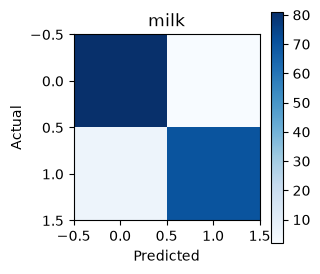


eggs confusion matrix:
[[149   0]
 [  1   9]]


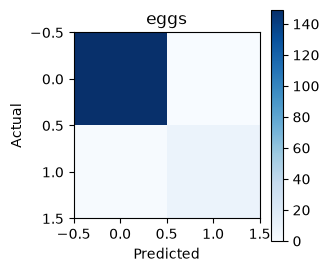


peanuts confusion matrix:
[[154   1]
 [  0   4]]


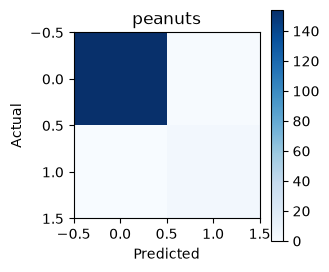


tree_nuts confusion matrix:
[[110   4]
 [  2  43]]


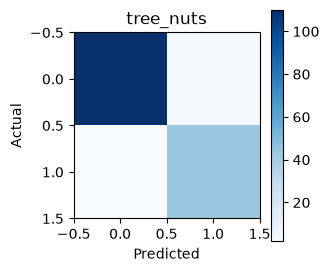


soy confusion matrix:
[[103   4]
 [  0  52]]


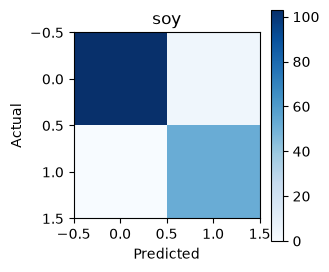


wheat confusion matrix:
[[100   0]
 [  1  58]]


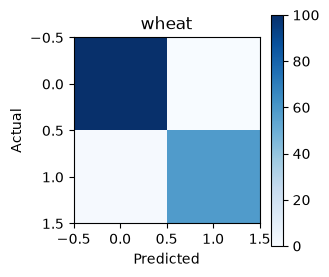


fish confusion matrix:
[[147   0]
 [  0  12]]


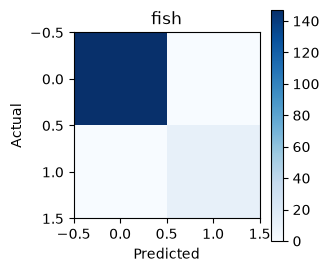


shellfish confusion matrix:
[[154   0]
 [  2   3]]


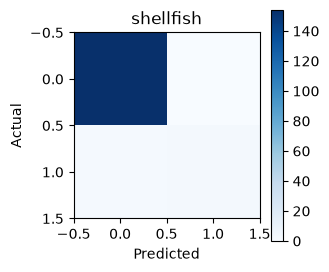

In [23]:
mcm = multilabel_confusion_matrix(test_labels_true, test_preds)
for i, allergen in enumerate(ALLERGENS):
    print(f"\n{allergen} confusion matrix:")
    print(mcm[i])
    
    # Plot
    plt.figure(figsize=(3,3))
    plt.imshow(mcm[i], cmap='Blues')
    plt.title(allergen)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.show()

## 13. Error Analysis
Show some misclassified examples to understand model weaknesses.

In [24]:
results_df = pd.DataFrame({
    "text": val_texts,
    "true": val_labels.tolist(),
    "pred": val_preds_opt.tolist()
})
errors = results_df[results_df["true"] != results_df["pred"]]
print(f"Number of misclassified validation samples: {len(errors)}")
if len(errors) > 0:
    print("\nFirst 5 errors:")
    for i in range(min(5, len(errors))):
        row = errors.iloc[i]
        true_labels = [ALLERGENS[j] for j, v in enumerate(row['true']) if v == 1]
        pred_labels = [ALLERGENS[j] for j, v in enumerate(row['pred']) if v == 1]
        print(f"\nText: {row['text'][:150]}...")
        print(f"True: {true_labels}")
        print(f"Pred: {pred_labels}")

Number of misclassified validation samples: 8

First 5 errors:

Text: cracker ,wheat flour, vegetable fat ,may contain one or more of the following coconut, palm or palm kernel, active dry yeast, iodized salt, malt extra...
True: ['tree_nuts', 'wheat']
Pred: ['milk', 'tree_nuts', 'wheat']

Text: exp date mar...
True: []
Pred: ['eggs', 'tree_nuts', 'soy']

Text: fresh potatoes, pure vegetable oil ,contains one or more of the following olein oil, safflower oil, sunflower oil, ketchup seasoning ,sugar, salt, tom...
True: []
Pred: ['tree_nuts']

Text: garlic rice steamed rice ,water, rice grain rice improver ,disaccharide and calcium oxide ,as natural preservative, and citric acid ,acidity regulator...
True: ['milk', 'eggs', 'soy', 'wheat', 'fish']
Pred: ['milk', 'eggs', 'soy', 'wheat']

Text: biscuit base ,contains wheat flour, hydrogenated vegetable fat coconut, palm, antioxidant ,tbhq, sugar, cornstarch, glucose, raising agents sodium bic...
True: ['milk', 'tree_nuts', 'soy', 'wheat']
P

## 14. Save Final Model

In [25]:
import shutil
import os

final_dir = "../models/mobilebert_allergen_final"
if os.path.exists(final_dir):
    shutil.rmtree(final_dir)   
    
trainer.save_model(final_dir)
tokenizer.save_pretrained(final_dir)
print(f"Model saved to {final_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ../models/mobilebert_allergen_final
